This project investigates whether the spatial distribution of U.S. national parks influences how often they are visited. The central question is intuitive but surprisingly under-examined: do parks that sit near other parks benefit from that proximity?

For this project, our claim is that American National Parks visitation rates are higher in regions where national parks are geographically closer together, suggesting travelers are more likely to visit multiple parks within a dense cluster.

Three guiding questions structure the analysis:

- Are parks in more clustered areas visited more often (i.e., in areas where multi-park visitation is more feasible)?
- Given how far apart parks are, how much visitation does a typical park get?
- Do parks with more nearby neighbors receive more visits?

This hypothesis is based on the intuitive assumption that geographic proximity facilitates multi-park trips, potentially through reduced travel costs, shared infrastructure, and the ability to visit multiple destinations in a single vacation. If correct, we would expect tightly clustered parks to show higher per-park visitation rates than regions with widely dispersed parks.

## Data choices and justifications

Our first significant data choice was calculating the distances between the parks in each region. As the class dataset did not include geographical data, we decided to import an external dataset and matched parks by name to merge the data. After some light data cleaning to remove duplicates and standardize park names, we utilized the latitude and longitude in the Haversine Formula to calculate the distance between all pairs of parks across regions. We chose to use this formula due to its ability to calculate distances across a sphere using these coordinates accurately, as mentioned in the educational data science site [GeeksForGeeks](https://www.geeksforgeeks.org/dsa/haversine-formula-to-find-distance-between-two-points-on-a-sphere).

Additionally, after finding the Haversine distance between each park, we used a multiplier of 1.4 on each value to account for the variations in road structures (as the distances between each park are likely not straight lines). According to a [study published in the National Library of Medicine](https://doi.org/10.1080/00330124.2011.583586) titled "A Nationwide Comparison of Driving Distance Versus Straight-Line Distance to Hospitals", in nearly "all locations within the United States," applying a detour index of about 1.4 to the "straight-line distance" is an "adequate proxy for travel distance". Though this does not account for more severe detours or uncrossable geographic features (roadblocks, lakes, rivers, etc.), we thought it was a good first step to take to approximate the distance (in miles).

Finally, among our three approaches (discussed below in more detail), one approach involved investigating whether parks closer to metropolitan areas showed any changes in visitation compared to more remote areas. To do this, we used the [US Metro Areas Database](https://simplemaps.com/data/us-metros), which contains coordinates and population data. Then, for each metro area, we used the same Haversine distance calculation to calculate its distance between all parks, only keeping the parks that were within a 300-mile radius of a metro area to ensure we only examined parks that were reasonably accessible from major metropolitan cities (and minimizing any potential bias, such as parks with very low visits or that were remote).

In [2]:
#| echo: false
from pathlib import Path
from itertools import combinations
from math import radians, sin, cos, asin, sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)

In [3]:
#| echo: false
NOTEBOOK_ROOT = Path('.').resolve()
PROJECT_ROOT = NOTEBOOK_ROOT.parent

PROCESSED = PROJECT_ROOT / 'processed'
RESULTS = NOTEBOOK_ROOT / 'results'
RESULTS.mkdir(parents=True, exist_ok=True)

# Prefer the same source used by revised_park_analysis so outputs match.
raw_parks_path = PROJECT_ROOT / 'total_visitation.txt'
metros_path = PROJECT_ROOT / 'usmetros.csv'

if raw_parks_path.exists():
    parks_df = pd.read_csv(raw_parks_path)
    if 'Unnamed: 0' in parks_df.columns:
        parks_df = parks_df.drop(columns=['Unnamed: 0'])
else:
    parks_path = PROCESSED / 'parks_master.csv'
    if not parks_path.exists():
        raise FileNotFoundError('Run preprocess_data.py first to create processed inputs.')
    parks_df = pd.read_csv(parks_path)

if not metros_path.exists():
    metros_path = PROCESSED / 'usmetros_clean.csv'

if not metros_path.exists():
    raise FileNotFoundError('Missing metro data. Expected usmetros.csv or processed/usmetros_clean.csv')

metros_df = pd.read_csv(metros_path)

# Normalize exactly once at park level so region comparisons are fair.
parks_df['Region'] = parks_df['Region'].astype(str).str.strip()
parks_df['RecreationVisits'] = pd.to_numeric(parks_df['RecreationVisits'], errors='coerce')
parks_df['Latitude'] = pd.to_numeric(parks_df['Latitude'], errors='coerce')
parks_df['Longitude'] = pd.to_numeric(parks_df['Longitude'], errors='coerce')
parks_df = parks_df.dropna(subset=['Latitude', 'Longitude', 'RecreationVisits'])

keep_cols = ['ParkName', 'Region', 'Latitude', 'Longitude']
if 'clean_name' in parks_df.columns:
    keep_cols.insert(1, 'clean_name')
parks_df = parks_df.groupby(keep_cols, as_index=False)['RecreationVisits'].sum()

metros_df['population'] = pd.to_numeric(metros_df['population'], errors='coerce')
metros_df['lat'] = pd.to_numeric(metros_df['lat'], errors='coerce')
metros_df['lng'] = pd.to_numeric(metros_df['lng'], errors='coerce')
metros_df = metros_df.dropna(subset=['population', 'lat', 'lng'])

In [4]:
#| echo: false
def haversine_miles(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(min(1, sqrt(a)))
    return 3958.8 * c

def road_miles(lon1, lat1, lon2, lat2, detour=1.4):
    return haversine_miles(lon1, lat1, lon2, lat2) * detour

## Approaches

We used three complementary spatial approaches to test our hypothesis at different scales.

### Approach 1: neighbor count

For this approach, we used a pairwise distance calculation, combined with a Pearson Correlation (r) analysis, to test the relationship between park clustering and visitation at an individual park level. For neighbor counting, we defined a spatial radius of 300 miles, which is roughly a 4–6 hour drive. For each park, we counted the number of other parks within this radius and grouped the parks into categories: Isolated (0), Few (1–2), Some (3–5), and Many (6+) neighbors. In addition to calculating the correlation (r) based on the neighbor count (independent variable) and the total recreation visits for each park (dependent variable), we explored the visitation distributions across these categories through summary statistics and box plots.

### Approach 2: grid-based analysis

For this approach, we used geographical binning (as well as per-park normalization and correlation analysis to minimize any effects regional distribution may have had) to test clustering effects at a tighter spatial scale. To do this, we divided the U.S. into a grid (we chose 150 by 150 miles, roughly) and converted the grid size from miles to degrees, approximated using 1 degree ≈ 69 miles for both latitude and longitude. While this created some distortion at higher latitudes, most parks fell within similar latitude bands, minimizing the effect.

For each grid square, we calculated park count, total visits, and average visit per park (total visits divided by park count). Without this normalization, grids with more parks would automatically have higher total visits. By averaging visits per park, the analysis isolates the effect of density rather than just quantity.

To have meaningful clustering comparisons, we also only counted the grids that contained at least two parks. We calculated r based on the number of parks in each grid (our independent variable) and the average visits per park in that grid (dependent variable).

### Approach 3: metro areas

For each metropolitan area, we identified all parks within a radius and calculated park count near that metro, total visits from all nearby parks, and average visits per park. This normalization was, again, essential, as metros surrounded by many parks should not automatically appear as more "successful" simply because they had more parks within their radius. By normalizing to average visits per park, we were able to test whether individual parks near clustered metro areas receive more visits than parks near metro areas with fewer park options, potentially due to shared tourism infrastructure or marketing.

This approach also allowed us to examine whether metro population size correlates with park visitation, helping distinguish between clustering effects and general urban accessibility effects.

## Findings and analysis

### Region-level proximity and visitation

The first analysis uses region-level network density to test the broad claim that parks in denser networks attract more visitors.

In [21]:
#| echo: false
REGION_EDGE_THRESHOLD = 500
rows = []

for region, g in parks_df.groupby('Region'):
    g = g.reset_index(drop=True)
    n = len(g)

    gc_dists = []
    road_dists = []
    edge_count = 0

    for i, j in combinations(range(n), 2):
        gc = haversine_miles(g.loc[i, 'Longitude'], g.loc[i, 'Latitude'], g.loc[j, 'Longitude'], g.loc[j, 'Latitude'])
        rd = gc * 1.4
        gc_dists.append(gc)
        road_dists.append(rd)

        # Match EDA network thresholding: edges are built on straight-line miles.
        if gc <= REGION_EDGE_THRESHOLD:
            edge_count += 1

    possible_edges = (n * (n - 1)) / 2 if n > 1 else np.nan
    density = edge_count / possible_edges if possible_edges and possible_edges > 0 else np.nan

    total_visits = g['RecreationVisits'].sum()
    avg_visits_per_park = total_visits / n if n > 0 else np.nan

    rows.append({
        'Region': region,
        'ParkCount': n,
        'TotalVisits': total_visits,
        'AvgVisitsPerPark': avg_visits_per_park,
        'MedianVisitsPerPark': g['RecreationVisits'].median(),
        'AvgInterParkRoadMiles': np.mean(road_dists) if road_dists else np.nan,
        'MedianInterParkRoadMiles': np.median(road_dists) if road_dists else np.nan,
        'NetworkDensity500': density,
    })

region_summary = pd.DataFrame(rows).sort_values('AvgVisitsPerPark', ascending=False)
r_region = region_summary['NetworkDensity500'].corr(region_summary['AvgVisitsPerPark'])

region_summary.to_csv(RESULTS / 'region_summary_combined.csv', index=False)
print(f'Region density vs avg visits-per-park correlation: r = {r_region:.3f}')
region_summary

Region density vs avg visits-per-park correlation: r = -0.575


,Region,ParkCount,TotalVisits,AvgVisitsPerPark,MedianVisitsPerPark,AvgInterParkRoadMiles,MedianInterParkRoadMiles,NetworkDensity500
5,Southeast,7,591324837,8.447498e+07,24954616.0,1081.837114,1025.174201,0.285714
3,Northeast,3,243951367,8.131712e+07,68391485.0,750.387388,924.900170,0.333333
1,Intermountain,19,1117964867,5.884026e+07,31377677.0,634.390994,577.978245,0.649123
2,Midwest,9,462819570,5.142440e+07,45958032.0,929.758775,999.985921,0.250000
4,Pacific West,17,745932335,4.387837e+07,30814121.0,1936.122882,940.160945,0.419118
0,Alaska,8,48189933,6.023742e+06,1905470.0,627.458897,649.480598,0.607143


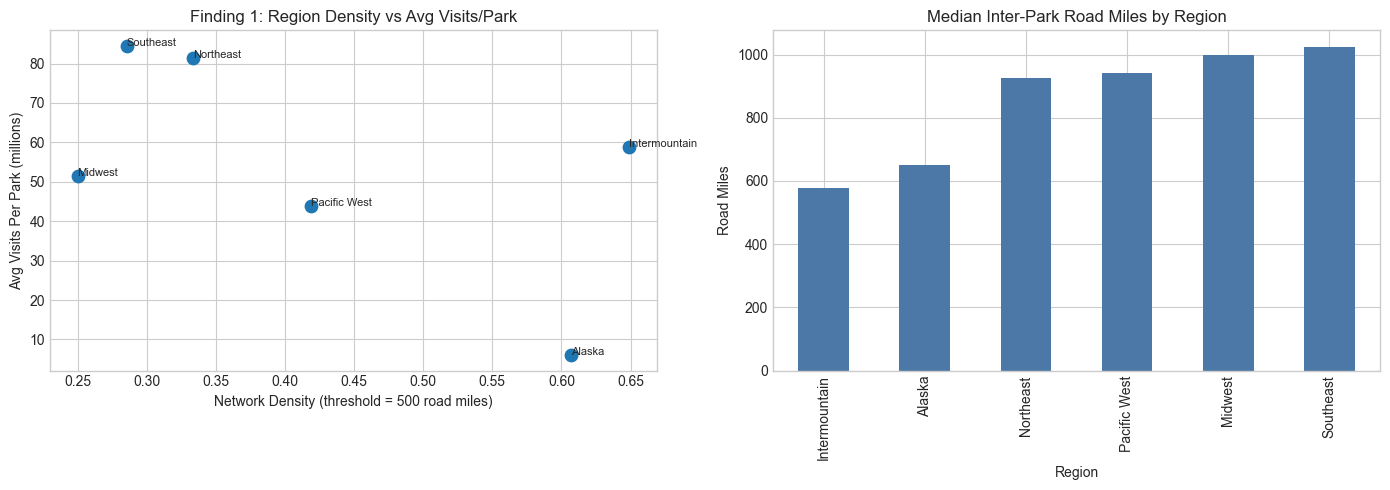

In [22]:
#| echo: false
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(region_summary['NetworkDensity500'], region_summary['AvgVisitsPerPark'] / 1e6, s=80)
for _, row in region_summary.iterrows():
    axes[0].annotate(row['Region'], (row['NetworkDensity500'], row['AvgVisitsPerPark'] / 1e6), fontsize=8)
axes[0].set_title('Finding 1: Region Density vs Avg Visits/Park')
axes[0].set_xlabel('Network Density (threshold = 500 road miles)')
axes[0].set_ylabel('Avg Visits Per Park (millions)')

region_summary.sort_values('MedianInterParkRoadMiles').plot(
    x='Region', y='MedianInterParkRoadMiles', kind='bar', ax=axes[1], legend=False, color='#4C78A8'
)
axes[1].set_title('Median Inter-Park Road Miles by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Road Miles')

plt.tight_layout()

### Neighbor count analysis

Our neighbor count analysis had a correlation coefficient of r = 0.020, indicating that there is virtually no correlation between the number of neighbors a park has and its visitation at the 300-mile scale.

Our hypothesis is not supported at the individual park level. For example, Acadia Park, which is completely isolated, received 4.5 times more visits than Capitol Reef, which had 8 neighbors (the highest neighbor count). Capitol Reef, besides being the most clustered park, had 30M visits, and Bryce Canyon was right behind (7 neighbors, 54M visits). Despite having zero neighbors (within the 300-mile radius), Acadia still received 134M visits. This is perhaps the clearest example that proximity to other parks does not predict higher visitation.

In [23]:
#| echo: false
NEIGHBOR_RADIUS = 300
neighbor_rows = []

for i, park in parks_df.reset_index(drop=True).iterrows():
    neighbors = []
    for j, other in parks_df.reset_index(drop=True).iterrows():
        if i == j:
            continue
        d = road_miles(park['Longitude'], park['Latitude'], other['Longitude'], other['Latitude'])
        if d <= NEIGHBOR_RADIUS:
            neighbors.append((other['ParkName'], d))

    neighbors_sorted = sorted(neighbors, key=lambda x: x[1])
    neighbor_rows.append({
        'ParkName': park['ParkName'],
        'Region': park['Region'],
        'TotalVisits': park['RecreationVisits'],
        'NeighborCount': len(neighbors_sorted),
        'Closest3Neighbors': ', '.join([n for n, _ in neighbors_sorted[:3]])
    })

neighbor_df = pd.DataFrame(neighbor_rows).sort_values(['NeighborCount', 'TotalVisits'], ascending=[False, False])
r_neighbor = neighbor_df['NeighborCount'].corr(neighbor_df['TotalVisits'])

neighbor_df.to_csv(RESULTS / 'neighbor_count_results_combined.csv', index=False)

print(f'Neighbor count vs total visits correlation: r = {r_neighbor:.3f}')
neighbor_df.head(10)

Neighbor count vs total visits correlation: r = 0.020


,ParkName,Region,TotalVisits,NeighborCount,Closest3Neighbors
8,Capitol Reef NP,Intermountain,29963941,8,"Canyonlands NP, Bryce Canyon NP, Arches NP"
6,Bryce Canyon NP,Intermountain,54254911,7,"Zion NP, Capitol Reef NP, Grand Canyon NP"
41,Mesa Verde NP,Intermountain,25517152,7,"Black Canyon of the Gunnison NP, Canyonlands N..."
7,Canyonlands NP,Intermountain,18491617,7,"Arches NP, Capitol Reef NP, Mesa Verde NP"
62,Zion NP,Intermountain,119116876,6,"Bryce Canyon NP, Grand Canyon NP, Capitol Reef NP"
1,Arches NP,Intermountain,39675085,6,"Canyonlands NP, Capitol Reef NP, Black Canyon ..."
5,Black Canyon of the Gunnison NP,Intermountain,10973033,6,"Arches NP, Mesa Verde NP, Canyonlands NP"
22,Grand Canyon NP,Intermountain,186529149,5,"Zion NP, Bryce Canyon NP, Petrified Forest NP"
61,Yosemite NP,Pacific West,155709017,5,"Kings Canyon NP, Sequoia NP, Pinnacles NP"
52,Sequoia NP,Pacific West,45109693,5,"Kings Canyon NP, Death Valley NP, Yosemite NP"


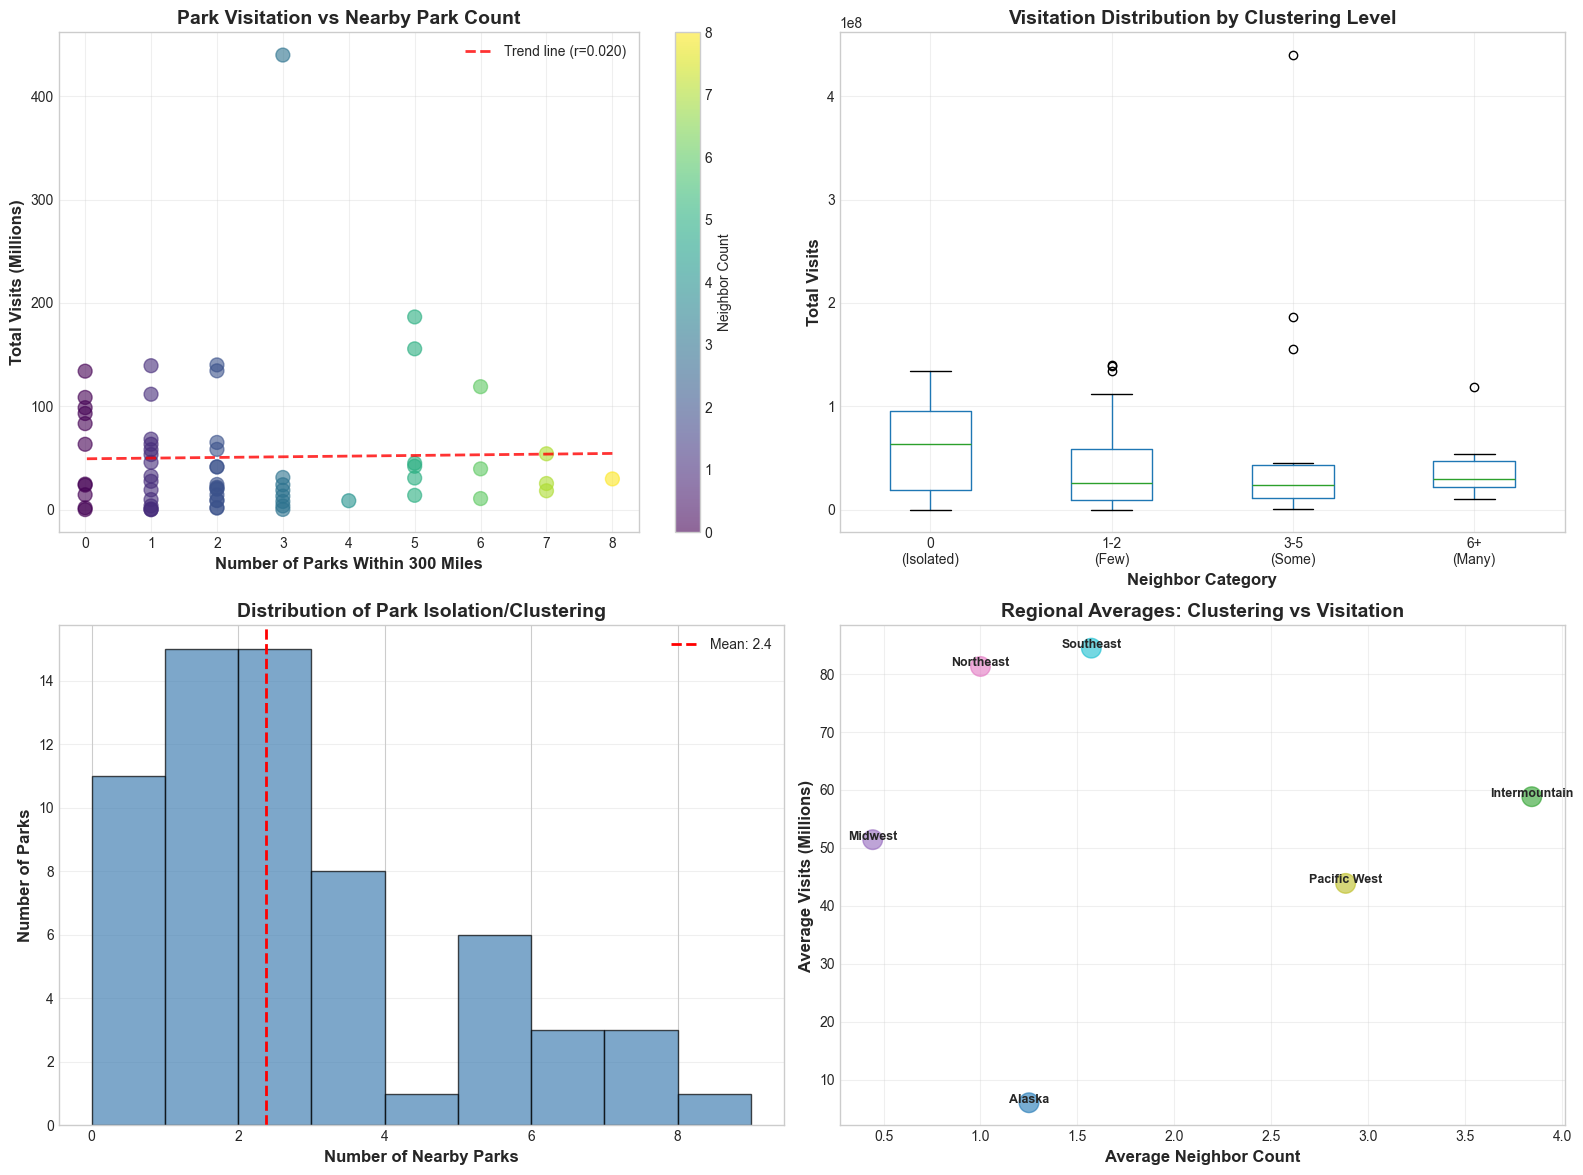

In [29]:
#| echo: false
# Restored 4-panel neighbor-count visualization.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
scatter = ax1.scatter(
    neighbor_df['NeighborCount'],
    neighbor_df['TotalVisits'] / 1e6,
    alpha=0.6,
    s=100,
    c=neighbor_df['NeighborCount'],
    cmap='viridis',
)
ax1.set_xlabel(f'Number of Parks Within {NEIGHBOR_RADIUS} Miles', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Visits (Millions)', fontsize=12, fontweight='bold')
ax1.set_title('Park Visitation vs Nearby Park Count', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Neighbor Count')

z = np.polyfit(neighbor_df['NeighborCount'], neighbor_df['TotalVisits'] / 1e6, 1)
p = np.poly1d(z)
ax1.plot(
    neighbor_df['NeighborCount'],
    p(neighbor_df['NeighborCount']),
    'r--',
    alpha=0.8,
    linewidth=2,
    label=f'Trend line (r={r_neighbor:.3f})',
)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
neighbors_cat = neighbor_df.copy()
neighbors_cat['NeighborCategory'] = pd.cut(
    neighbors_cat['NeighborCount'],
    bins=[-0.5, 0.5, 2.5, 5.5, 100],
    labels=['0\n(Isolated)', '1-2\n(Few)', '3-5\n(Some)', '6+\n(Many)'],
)
neighbors_cat.boxplot(column='TotalVisits', by='NeighborCategory', ax=ax2)
ax2.set_xlabel('Neighbor Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Visits', fontsize=12, fontweight='bold')
ax2.set_title('Visitation Distribution by Clustering Level', fontsize=14, fontweight='bold')
plt.suptitle('')
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
ax3.hist(
    neighbor_df['NeighborCount'],
    bins=range(0, int(neighbor_df['NeighborCount'].max()) + 2),
    edgecolor='black',
    alpha=0.7,
    color='steelblue',
)
ax3.set_xlabel('Number of Nearby Parks', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Parks', fontsize=12, fontweight='bold')
ax3.set_title('Distribution of Park Isolation/Clustering', fontsize=14, fontweight='bold')
ax3.axvline(
    neighbor_df['NeighborCount'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean: {neighbor_df['NeighborCount'].mean():.1f}",
)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

ax4 = axes[1, 1]
regional_avg = neighbor_df.groupby('Region', as_index=False).agg(
    NeighborCount=('NeighborCount', 'mean'),
    TotalVisits=('TotalVisits', 'mean'),
)
ax4.scatter(
    regional_avg['NeighborCount'],
    regional_avg['TotalVisits'] / 1e6,
    s=200,
    alpha=0.6,
    c=range(len(regional_avg)),
    cmap='tab10',
)
for _, row in regional_avg.iterrows():
    ax4.annotate(
        row['Region'],
        (row['NeighborCount'], row['TotalVisits'] / 1e6),
        fontsize=9,
        ha='center',
        fontweight='bold',
    )
ax4.set_xlabel('Average Neighbor Count', fontsize=12, fontweight='bold')
ax4.set_ylabel('Average Visits (Millions)', fontsize=12, fontweight='bold')
ax4.set_title('Regional Averages: Clustering vs Visitation', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Grid-based analysis

For our grid-based approach, we found a strong, positive correlation between park proximity and the number of visits. From the 54 grids we created, only seven grids had more than two parks — five grids had two parks, and two grids had three parks. The correlation coefficient of r = 0.934, though extremely strong, only occurred because we controlled for regional differences (through creating grids). After creating our grids, we saw high-density clusters (e.g. Bryce/Grand Canyon/Zion Parks, with an average of 120M visits per park; Kings Canyon/Sequoia/Yosemite Parks, with an average of 77M visits) as well as grids with lower density (e.g. Carlsbad/Guadalupe Parks with an average of 16M). This suggests the visitation benefits of clustering, in our grid analysis, only occur at tighter spatial scales. When we increase the threshold from 150 to 300 miles, for example, we get 14 grid squares with more than two parks and one grid square with five parks. The correlation then becomes −0.105, suggesting that at an even slightly broader threshold, the clustering "benefits" for visitations disappear. Once parks are more spaced out, other influencing factors, such as accessibility or regional tourism, take precedence over clustering.

In [24]:
#| echo: false
def grid_analysis(df, grid_miles=150, min_parks=2):
    grid_deg = grid_miles / 69.0
    lon0 = df['Longitude'].min()
    lat0 = df['Latitude'].min()

    work = df.copy()
    work['grid_x'] = ((work['Longitude'] - lon0) / grid_deg).astype(int)
    work['grid_y'] = ((work['Latitude'] - lat0) / grid_deg).astype(int)
    work['GridID'] = work['grid_x'].astype(str) + '_' + work['grid_y'].astype(str)

    grouped = work.groupby('GridID', as_index=False).agg(
        ParkCount=('ParkName', 'count'),
        TotalVisits=('RecreationVisits', 'sum')
    )
    grouped['AvgVisitsPerPark'] = grouped['TotalVisits'] / grouped['ParkCount']
    grouped = grouped[grouped['ParkCount'] >= min_parks].copy()

    if len(grouped) > 1:
        corr = grouped['ParkCount'].corr(grouped['AvgVisitsPerPark'])
    else:
        corr = np.nan

    return grouped.sort_values(['ParkCount', 'AvgVisitsPerPark'], ascending=[False, False]), corr

grid_150, r_grid_150 = grid_analysis(parks_df, grid_miles=150, min_parks=2)
grid_300, r_grid_300 = grid_analysis(parks_df, grid_miles=300, min_parks=2)

grid_150.to_csv(RESULTS / 'grid_analysis_150_combined.csv', index=False)
grid_300.to_csv(RESULTS / 'grid_analysis_300_combined.csv', index=False)

print(f'Grid 150 miles: r = {r_grid_150:.3f} (n={len(grid_150)} grids)')
print(f'Grid 300 miles: r = {r_grid_300:.3f} (n={len(grid_300)} grids)')
grid_150.head(10)

Grid 150 miles: r = 0.934 (n=7 grids)
Grid 300 miles: r = -0.105 (n=14 grids)


,GridID,ParkCount,TotalVisits,AvgVisitsPerPark
14,26_23,3,359900936,1.199670e+08
10,23_23,3,231632831,7.721094e+07
8,22_28,2,67511157,3.375558e+07
40,41_18,2,62514626,3.125731e+07
22,28_24,2,50648118,2.532406e+07
17,27_24,2,48455558,2.422778e+07
26,30_21,2,32479413,1.623971e+07


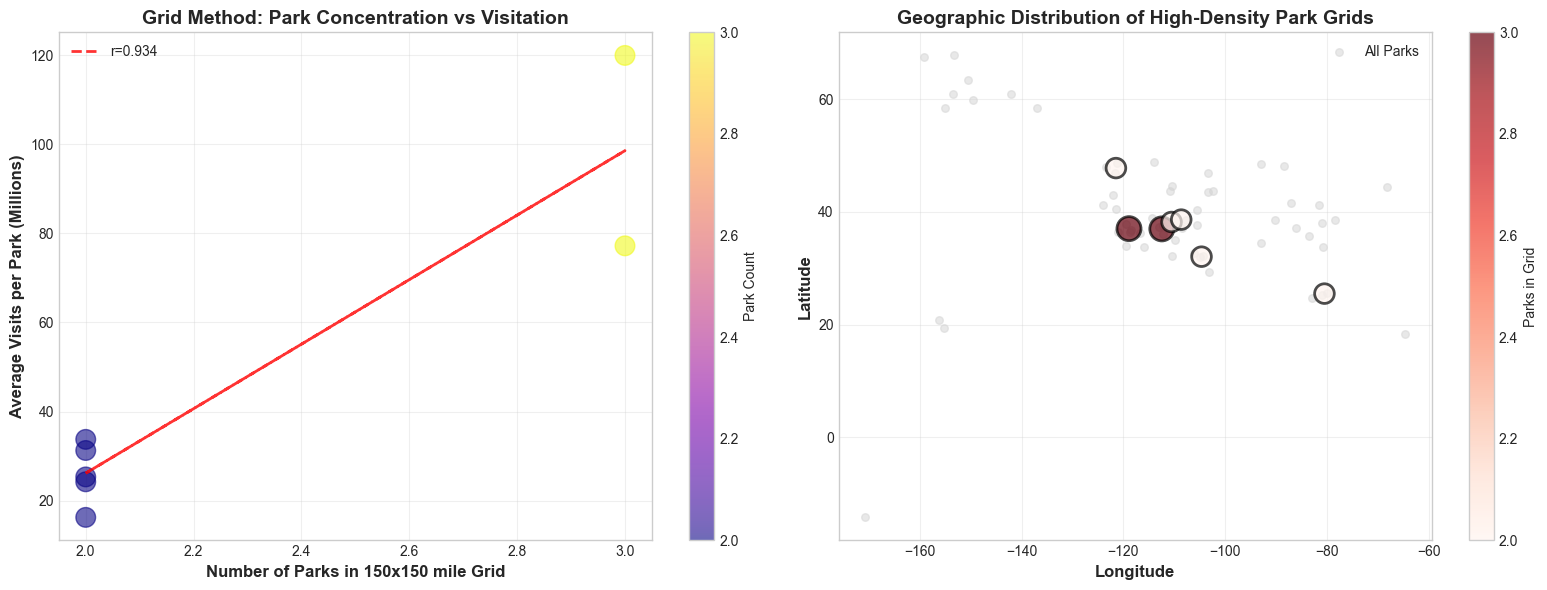

In [30]:
#| echo: false
# Restored grid visualizations: concentration-vs-visits and geographic map.
if len(grid_150) > 0:
    parks_grid = parks_df.copy()
    grid_size_degrees = 150 / 69.0
    lat_min = parks_grid['Latitude'].min()
    lon_min = parks_grid['Longitude'].min()
    parks_grid['grid_lat'] = ((parks_grid['Latitude'] - lat_min) / grid_size_degrees).astype(int)
    parks_grid['grid_lon'] = ((parks_grid['Longitude'] - lon_min) / grid_size_degrees).astype(int)
    parks_grid['grid_id'] = parks_grid['grid_lat'].astype(str) + '_' + parks_grid['grid_lon'].astype(str)

    grid_stats = parks_grid.groupby('grid_id', as_index=False).agg(
        park_count=('ParkName', 'count'),
        total_visits=('RecreationVisits', 'sum'),
        center_lat=('Latitude', 'mean'),
        center_lon=('Longitude', 'mean'),
    )
    grid_stats['avg_visits_per_park'] = grid_stats['total_visits'] / grid_stats['park_count']
    grid_stats_filtered = grid_stats[grid_stats['park_count'] >= 2].copy()
    grid_correlation = grid_stats_filtered['park_count'].corr(grid_stats_filtered['avg_visits_per_park'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax1 = axes[0]
    scatter = ax1.scatter(
        grid_stats_filtered['park_count'],
        grid_stats_filtered['avg_visits_per_park'] / 1e6,
        s=200,
        alpha=0.6,
        c=grid_stats_filtered['park_count'],
        cmap='plasma',
    )
    ax1.set_xlabel('Number of Parks in 150x150 mile Grid', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Average Visits per Park (Millions)', fontsize=12, fontweight='bold')
    ax1.set_title('Grid Method: Park Concentration vs Visitation', fontsize=14, fontweight='bold')
    plt.colorbar(scatter, ax=ax1, label='Park Count')
    ax1.grid(True, alpha=0.3)

    z = np.polyfit(grid_stats_filtered['park_count'], grid_stats_filtered['avg_visits_per_park'] / 1e6, 1)
    p = np.poly1d(z)
    ax1.plot(
        grid_stats_filtered['park_count'],
        p(grid_stats_filtered['park_count']),
        'r--',
        alpha=0.8,
        linewidth=2,
        label=f'r={grid_correlation:.3f}',
    )
    ax1.legend()

    ax2 = axes[1]
    ax2.scatter(parks_df['Longitude'], parks_df['Latitude'], c='lightgray', s=30, alpha=0.5, label='All Parks')
    scatter2 = ax2.scatter(
        grid_stats_filtered['center_lon'],
        grid_stats_filtered['center_lat'],
        s=grid_stats_filtered['park_count'] * 100,
        c=grid_stats_filtered['park_count'],
        cmap='Reds',
        alpha=0.7,
        edgecolors='black',
        linewidth=2,
    )
    ax2.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax2.set_title('Geographic Distribution of High-Density Park Grids', fontsize=14, fontweight='bold')
    ax2.legend()
    plt.colorbar(scatter2, ax=ax2, label='Parks in Grid')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Metro areas

Our metro area analysis found that there was a slightly negative correlation between the number of parks in a metropolitan area and both average visits and average visits per park (−0.113 and −0.018, respectively). There were 282 metro areas with national parks within 300 miles of it. The parks that were closer to metro areas appeared to have fewer visits per park, rather than more. While a park’s proximity to urban areas doesn’t directly enhance clustering benefits, this may indicate that the parks have competition for visits (e.g. parks closer to metro areas may have to compete with restaurants, museums, and other entertainment options for visits). In other words, park proximity alone is not a sufficient driver for increased visitation.

In [ ]:
#| echo: false
METRO_RADIUS = 300
metro_rows = []

for _, metro in metros_df.iterrows():
    nearby = []
    for _, park in parks_df.iterrows():
        d = road_miles(metro['lng'], metro['lat'], park['Longitude'], park['Latitude'])
        if d <= METRO_RADIUS:
            nearby.append((park['ParkName'], park['RecreationVisits']))

    if nearby:
        total = sum(v for _, v in nearby)
        metro_rows.append({
            'MetroArea': metro['metro'],
            'State': metro['state_id'],
            'Population': metro['population'],
            'ParkCount': len(nearby),
            'TotalVisits': total,
            'AvgVisitsPerPark': total / len(nearby),
            'Parks': ', '.join([n for n, _ in nearby])
        })

metro_analysis = pd.DataFrame(metro_rows).sort_values(['ParkCount', 'AvgVisitsPerPark'], ascending=[False, False])
r_metro_count = metro_analysis['ParkCount'].corr(metro_analysis['AvgVisitsPerPark'])
r_metro_pop = metro_analysis['Population'].corr(metro_analysis['AvgVisitsPerPark'])

metro_analysis.to_csv(RESULTS / 'metro_analysis_results_combined.csv', index=False)

print(f'Metro park count vs avg visits-per-park: r = {r_metro_count:.3f}')
print(f'Metro population vs avg visits-per-park: r = {r_metro_pop:.3f}')
metro_analysis.head(5)

Metro park count vs avg visits-per-park: r = -0.113
Metro population vs avg visits-per-park: r = -0.019


,MetroArea,State,Population,ParkCount,TotalVisits,AvgVisitsPerPark,Parks
21,Las Vegas,NV,2336573,8,547083340,6.838542e+07,"Bryce Canyon NP, Death Valley NP, Grand Canyon..."
209,"Flagstaff, AZ",AZ,144472,7,465251323,6.646447e+07,"Bryce Canyon NP, Canyonlands NP, Capitol Reef ..."
160,"St. George, UT",UT,202452,7,454392049,6.491315e+07,"Bryce Canyon NP, Canyonlands NP, Capitol Reef ..."
44,Bakersfield,CA,913820,7,362031910,5.171884e+07,"Channel Islands NP, Death Valley NP, Joshua Tr..."
190,"Grand Junction, CO",CO,159681,7,278110335,3.973005e+07,"Arches NP, Black Canyon of the Gunnison NP, Ca..."
232,"Farmington, NM",NM,120675,7,169314178,2.418774e+07,"Arches NP, Black Canyon of the Gunnison NP, Ca..."
132,Prescott Valley,AZ,249081,6,489132599,8.152210e+07,"Bryce Canyon NP, Grand Canyon NP, Joshua Tree ..."
35,"Fresno, CA",CA,1180020,6,296808875,4.946815e+07,"Channel Islands NP, Death Valley NP, Kings Can..."
79,"Visalia, CA",CA,479468,6,296808875,4.946815e+07,"Channel Islands NP, Death Valley NP, Kings Can..."
122,San Luis Obispo,CA,281639,6,296808875,4.946815e+07,"Channel Islands NP, Death Valley NP, Kings Can..."


## Conclusion

Our hypothesis that geographic clustering increases park visitation is context-dependent. At the broad spatial scale (300-mile radius), clustering shows no effect (r = 0.020), suggesting individual park characteristics dominate visitation decisions. However, within tight geographic clusters (150-mile grids), we DO observe a very strong positive relationship (r = 0.934), indicating that when parks are "truly" close, multi-park tourism does boost visitation. This suggests a distance threshold: parks must be within day-trip distance (~150 miles) for clustering benefits to materialize.

In [26]:
#| echo: false
summary = pd.DataFrame([
    {'Analysis': 'Findings 1 - Region density vs avg visits/park', 'Correlation_r': r_region},
    {'Analysis': 'Findings 2 - Neighbor count (300 miles)', 'Correlation_r': r_neighbor},
    {'Analysis': 'Findings 2 - Grid analysis (150 miles)', 'Correlation_r': r_grid_150},
    {'Analysis': 'Findings 2 - Grid analysis (300 miles)', 'Correlation_r': r_grid_300},
    {'Analysis': 'Findings 2 - Metro park count vs avg visits/park', 'Correlation_r': r_metro_count},
    {'Analysis': 'Findings 2 - Metro population vs avg visits/park', 'Correlation_r': r_metro_pop},
])

summary.to_csv(RESULTS / 'combined_correlation_summary.csv', index=False)
summary

,Analysis,Correlation_r
0,Findings 1 - Region density vs avg visits/park,-0.575353
1,Findings 2 - Neighbor count (300 miles),0.020248
2,Findings 2 - Grid analysis (150 miles),0.933781
3,Findings 2 - Grid analysis (300 miles),-0.105252
4,Findings 2 - Metro park count vs avg visits/park,-0.112590
5,Findings 2 - Metro population vs avg visits/park,-0.018823


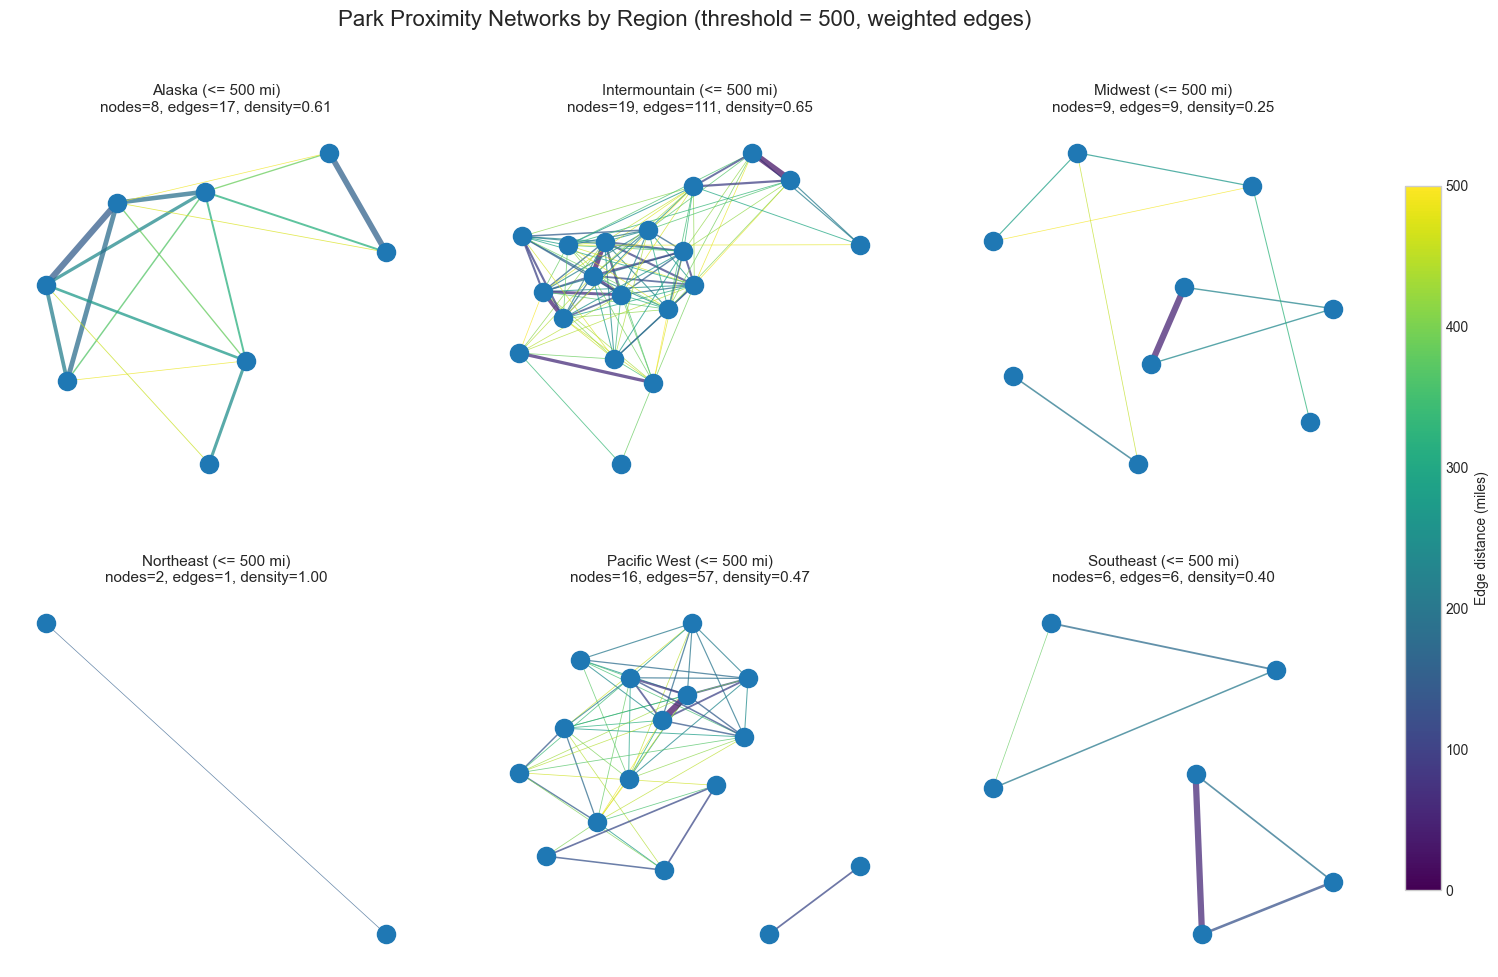

In [28]:
#| echo: false
# Park proximity networks by region (weighted edges, threshold 500 miles).
threshold = 500
regions = sorted(dist_clean['region'].unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
fig.subplots_adjust(right=0.88, wspace=0.15, hspace=0.25)
cax = fig.add_axes([0.90, 0.18, 0.02, 0.64])

cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=0, vmax=threshold)

for ax, region in zip(axes, regions):
    region_edges = dist_clean[
        (dist_clean['region'] == region)
        & (dist_clean['distance_miles'] > 0)
        & (dist_clean['distance_miles'] <= threshold)
    ].copy()

    G = nx.Graph()
    for _, row in region_edges.iterrows():
        d = float(row['distance_miles'])
        G.add_edge(row['from_park'], row['to_park'], distance=d, closeness=1.0 / d)

    if G.number_of_nodes() == 0:
        ax.set_title(f"{region}\n(no pairs <= {threshold} mi)")
        ax.axis('off')
        continue

    pos = nx.spring_layout(G, seed=42, weight='closeness')
    edges = list(G.edges())
    dists = np.array([G[u][v]['distance'] for u, v in edges])

    inv = 1 / dists
    widths = 0.5 + 4.0 * (inv - inv.min()) / (inv.max() - inv.min() + 1e-9)
    edge_colors = cmap(norm(dists))

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=widths, alpha=0.75)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=170)

    ax.set_title(
        f"{region} (<= {threshold} mi)\n"
        f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, density={nx.density(G):.2f}",
        fontsize=11,
    )
    ax.axis('off')

for j in range(len(regions), len(axes)):
    axes[j].axis('off')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Edge distance (miles)')

fig.suptitle('Park Proximity Networks by Region (threshold = 500, weighted edges)', fontsize=16, y=0.98)
plt.show()

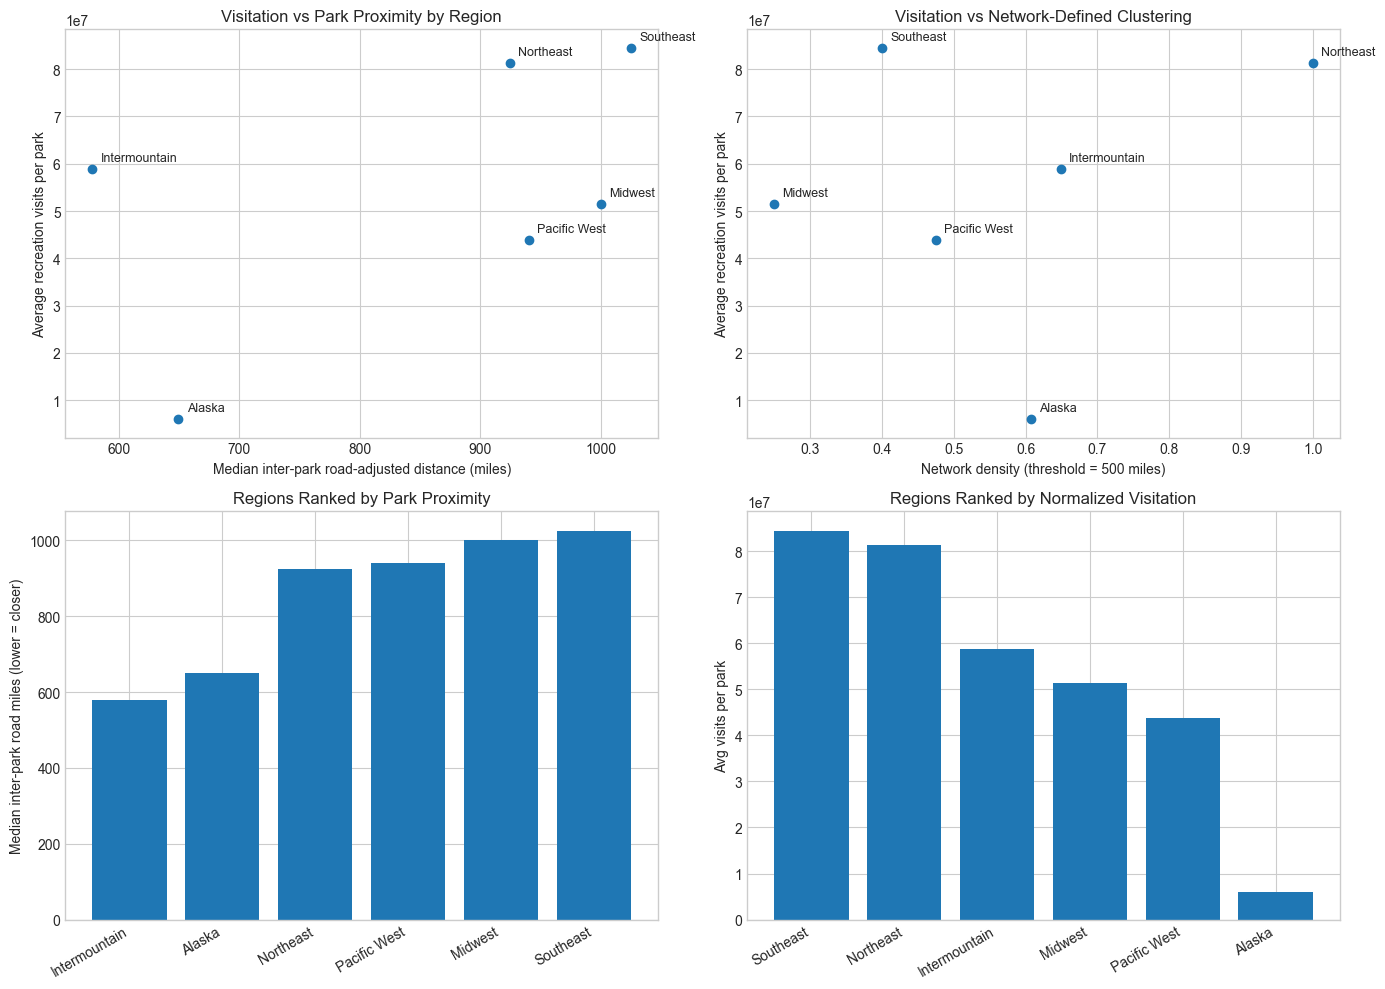

In [31]:
#| echo: false
# Restored regional diagnostic plots from EDA notebook.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.scatter(region_summary2['median_interpark_road_miles'], region_summary2['avg_visits_per_park'])
for _, r in region_summary2.iterrows():
    ax.annotate(r['region'], (r['median_interpark_road_miles'], r['avg_visits_per_park']), textcoords='offset points', xytext=(6, 6), fontsize=9)
ax.set_xlabel('Median inter-park road-adjusted distance (miles)')
ax.set_ylabel('Average recreation visits per park')
ax.set_title('Visitation vs Park Proximity by Region')

ax = axes[0, 1]
ax.scatter(region_summary2['network_density_500'], region_summary2['avg_visits_per_park'])
for _, r in region_summary2.iterrows():
    ax.annotate(r['region'], (r['network_density_500'], r['avg_visits_per_park']), textcoords='offset points', xytext=(6, 6), fontsize=9)
ax.set_xlabel('Network density (threshold = 500 miles)')
ax.set_ylabel('Average recreation visits per park')
ax.set_title('Visitation vs Network-Defined Clustering')

ax = axes[1, 0]
tmp = region_summary2.sort_values('median_interpark_road_miles')
ax.bar(tmp['region'], tmp['median_interpark_road_miles'])
ax.set_xticks(range(len(tmp['region'])))
ax.set_xticklabels(tmp['region'], rotation=30, ha='right')
ax.set_ylabel('Median inter-park road miles (lower = closer)')
ax.set_title('Regions Ranked by Park Proximity')

ax = axes[1, 1]
tmp2 = region_summary2.sort_values('avg_visits_per_park', ascending=False)
ax.bar(tmp2['region'], tmp2['avg_visits_per_park'])
ax.set_xticks(range(len(tmp2['region'])))
ax.set_xticklabels(tmp2['region'], rotation=30, ha='right')
ax.set_ylabel('Avg visits per park')
ax.set_title('Regions Ranked by Normalized Visitation')

plt.tight_layout()
plt.show()

## Appendix: summary tables

### Table 1.1: Neighbor count summary statistics

| Category | Count | Mean visits | Median visits | Std |
|----------|-------|-------------|---------------|-----|
| Isolated (0) | 19 | 72.7M | 48.3M | 73.7M |
| Few (1–2) | 15 | 56.4M | 34.9M | 58.0M |
| Some (3–5) | 13 | 51.3M | 30.3M | 54.1M |
| Many (6+) | 7 | 62.1M | 54.0M | 42.3M |

### Table 1.2: Example parks by neighbor count

| Park | Neighbors | Total recreation visits |
|------|-----------|------------------------|
| Acadia | 0 | 134M |
| Capitol Reef | 8 | 30M |
| Bryce Canyon | 7 | 54M |
| Great Smoky Mountains | 0 | 467M |

### Table 2: Grid-based clustering (150-mile grid, min 2 parks)

| Grid | Parks | Avg visits/park |
|------|-------|-----------------|
| Bryce/Grand Canyon/Zion | 3 | 120M |
| Kings Canyon/Sequoia/Yosemite | 3 | 77M |
| Carlsbad/Guadalupe | 2 | 16M |
| Cuyahoga/Congaree | 2 | 45M |
| Theodore Roosevelt/Wind Cave | 2 | 22M |

### Table 3: Correlation summary across approaches

| Approach | Scale | r | Interpretation |
|----------|-------|---|----------------|
| Neighbor count | 300 mi | 0.020 | No correlation |
| Grid (150 mi) | 150 mi | 0.934 | Strong positive |
| Grid (300 mi) | 300 mi | −0.105 | Slight negative |
| Metro (park count vs avg visits) | 300 mi | −0.113 | Slight negative |
| Metro (park count vs avg visits/park) | 300 mi | −0.018 | No correlation |

## Michigan zoom-in

This section uses the same 300-mile metro framework to check how the national mobility narrative translates to Michigan. Michigan supports the broader conclusion: access breadth is limited for many metros, which constrains multi-park chaining opportunities. Demand variation exists, but reachable park count and distance structure remain central mobility constraints.

In [32]:
#| echo: false
# Build Michigan-specific metro metrics using the same 300-mile radius framework.
MI_RADIUS = 300

all_metro_rows = []
for _, metro in metros_df.iterrows():
    nearby = []
    distances = []

    for _, park in parks_df.iterrows():
        d = road_miles(metro['lng'], metro['lat'], park['Longitude'], park['Latitude'])
        if d <= MI_RADIUS:
            nearby.append((park['ParkName'], park['RecreationVisits']))
            distances.append(d)

    if nearby:
        total = sum(v for _, v in nearby)
        all_metro_rows.append({
            'MetroArea': metro['metro'],
            'State': metro['state_id'],
            'Population': metro['population'],
            'ParkCount': len(nearby),
            'TotalVisits': total,
            'AvgVisitsPerPark': total / len(nearby),
            'MinDistance': min(distances),
            'MedianDistance': float(np.median(distances)),
            'Parks': ', '.join([n for n, _ in nearby]),
        })

all_metro_analysis = pd.DataFrame(all_metro_rows)
mi_metro_analysis = all_metro_analysis[all_metro_analysis['State'] == 'MI'].copy()

if mi_metro_analysis.empty:
    print('No Michigan metro areas with parks within 300 miles under current data and radius.')
else:
    mi_metro_analysis = mi_metro_analysis.sort_values(['ParkCount', 'AvgVisitsPerPark'], ascending=[False, False])
    print(f"Michigan metros analyzed: {len(mi_metro_analysis)}")

mi_metro_analysis.head(10)

Michigan metros analyzed: 14


,MetroArea,State,Population,ParkCount,TotalVisits,AvgVisitsPerPark,MinDistance,MedianDistance,Parks
10,Detroit,MI,4342304,2,182196811,91098405.5,187.418999,239.966300,"Cuyahoga Valley NP, Indiana Dunes NP"
80,Lansing,MI,473177,2,182196811,91098405.5,203.057118,232.509212,"Cuyahoga Valley NP, Indiana Dunes NP"
94,"Flint, MI",MI,401522,2,182196811,91098405.5,231.587500,252.481762,"Cuyahoga Valley NP, Indiana Dunes NP"
107,"Ann Arbor, MI",MI,365536,2,182196811,91098405.5,192.062305,215.199470,"Cuyahoga Valley NP, Indiana Dunes NP"
167,"Saginaw, MI",MI,187782,2,182196811,91098405.5,268.713666,269.579488,"Cuyahoga Valley NP, Indiana Dunes NP"
191,"Jackson, MI",MI,159424,2,182196811,91098405.5,197.692486,213.429534,"Cuyahoga Valley NP, Indiana Dunes NP"
200,"Monroe, MI",MI,155045,2,182196811,91098405.5,158.619140,206.681449,"Cuyahoga Valley NP, Indiana Dunes NP"
217,"Battle Creek, MI",MI,133366,2,182196811,91098405.5,158.031305,212.871561,"Cuyahoga Valley NP, Indiana Dunes NP"
257,"Bay City, MI",MI,102500,2,182196811,91098405.5,294.638693,295.068213,"Cuyahoga Valley NP, Indiana Dunes NP"
36,Grand Rapids,MI,1162950,1,83396931,83396931.0,174.372182,174.372182,Indiana Dunes NP


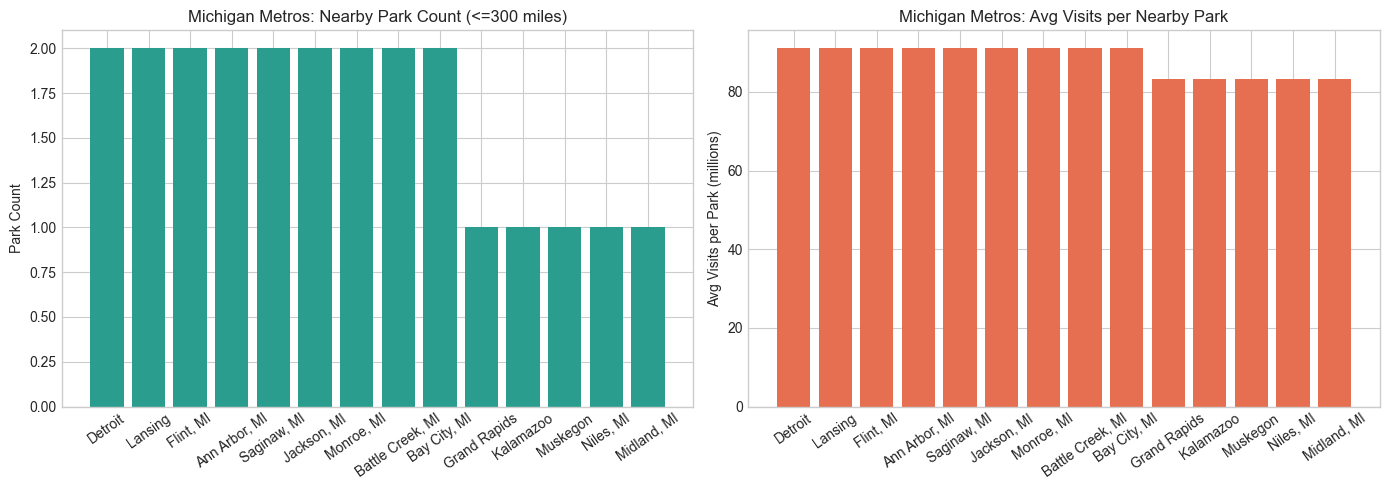

In [33]:
#| echo: false
# Visual 1: Michigan metro catchment profile.
if not mi_metro_analysis.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    tmp = mi_metro_analysis.sort_values('ParkCount', ascending=False)
    axes[0].bar(tmp['MetroArea'], tmp['ParkCount'], color='#2A9D8F')
    axes[0].set_title('Michigan Metros: Nearby Park Count (<=300 miles)')
    axes[0].set_ylabel('Park Count')
    axes[0].tick_params(axis='x', rotation=35)

    tmp2 = mi_metro_analysis.sort_values('AvgVisitsPerPark', ascending=False)
    axes[1].bar(tmp2['MetroArea'], tmp2['AvgVisitsPerPark'] / 1e6, color='#E76F51')
    axes[1].set_title('Michigan Metros: Avg Visits per Nearby Park')
    axes[1].set_ylabel('Avg Visits per Park (millions)')
    axes[1].tick_params(axis='x', rotation=35)

    plt.tight_layout()
    plt.show()

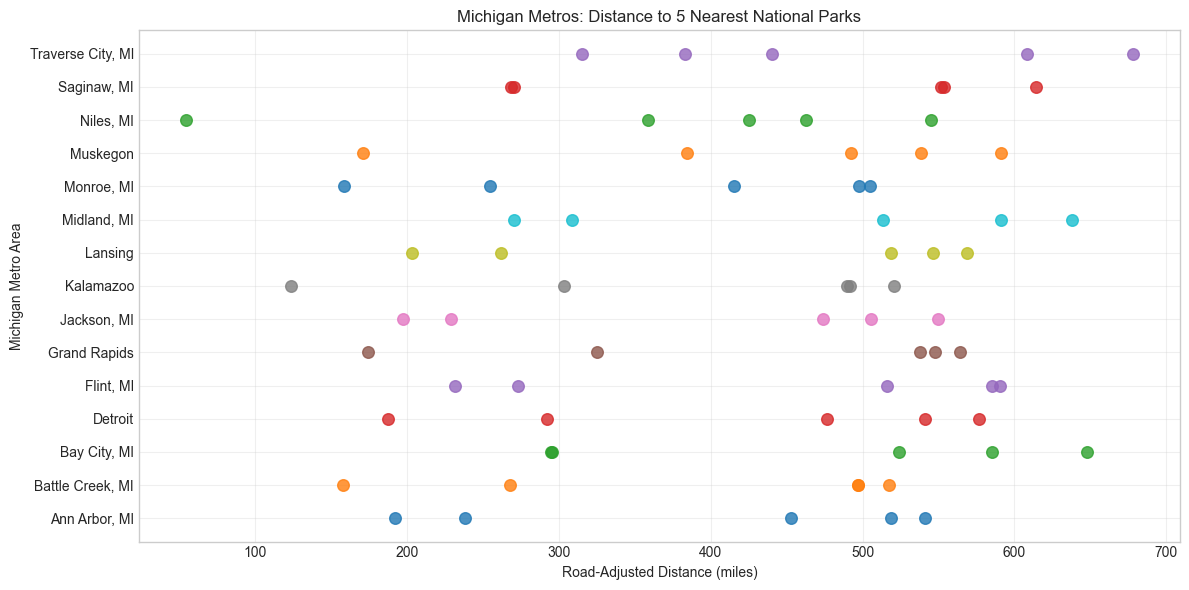

,MetroArea,Rank,ParkName,DistanceMiles
0,Detroit,1,Cuyahoga Valley NP,187.418999
1,Detroit,2,Indiana Dunes NP,292.513601
2,Detroit,3,New River Gorge NP & PRES,476.862841
3,Detroit,4,Shenandoah NP,540.872612
4,Detroit,5,Mammoth Cave NP,576.394526
5,Grand Rapids,1,Indiana Dunes NP,174.372182
6,Grand Rapids,2,Cuyahoga Valley NP,324.928538
7,Grand Rapids,3,Isle Royale NP,537.860967
8,Grand Rapids,4,Gateway Arch NP,547.534718
9,Grand Rapids,5,Mammoth Cave NP,564.259895


In [34]:
#| echo: false
# Visual 2: nearest-park distance profile (top 5 nearest parks per Michigan metro).
mi_distance_rows = []
for _, metro in metros_df[metros_df['state_id'] == 'MI'].iterrows():
    dlist = []
    for _, park in parks_df.iterrows():
        d = road_miles(metro['lng'], metro['lat'], park['Longitude'], park['Latitude'])
        dlist.append((park['ParkName'], d))

    dlist = sorted(dlist, key=lambda x: x[1])[:5]
    for rank, (park_name, d) in enumerate(dlist, start=1):
        mi_distance_rows.append({
            'MetroArea': metro['metro'],
            'Rank': rank,
            'ParkName': park_name,
            'DistanceMiles': d,
        })

mi_nearest5 = pd.DataFrame(mi_distance_rows)

if not mi_nearest5.empty:
    plt.figure(figsize=(12, 6))
    for metro_name, g in mi_nearest5.groupby('MetroArea'):
        plt.scatter(g['DistanceMiles'], [metro_name] * len(g), s=70, alpha=0.8, label=metro_name)

    plt.title('Michigan Metros: Distance to 5 Nearest National Parks')
    plt.xlabel('Road-Adjusted Distance (miles)')
    plt.ylabel('Michigan Metro Area')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

mi_nearest5.head(20)

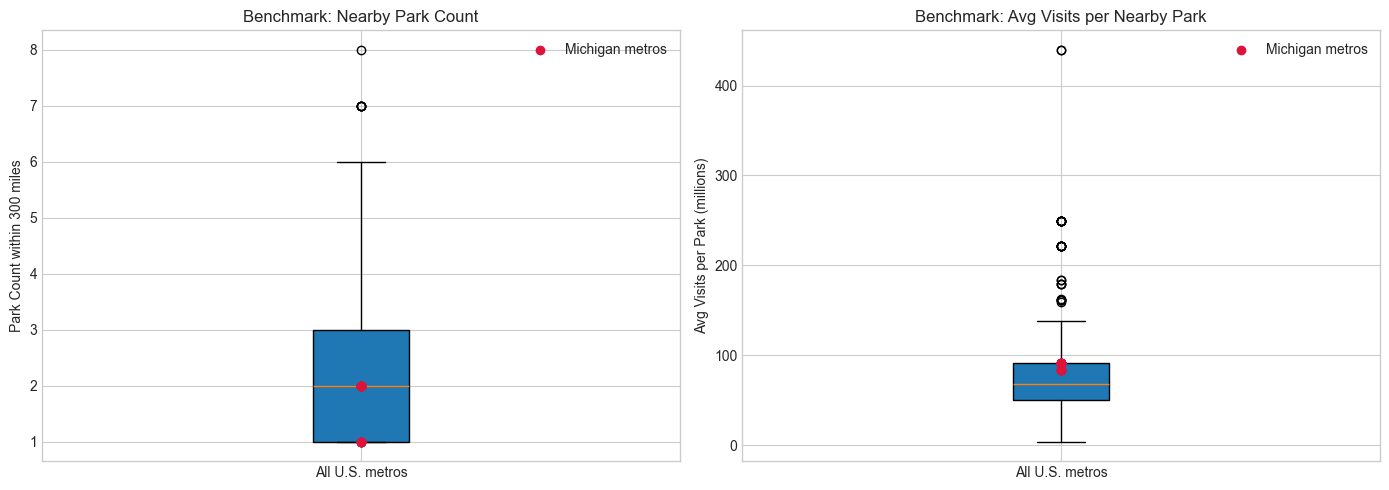

In [35]:
#| echo: false
# Visual 3: Michigan vs national benchmarks and Isle Royale sensitivity.
if not mi_metro_analysis.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].boxplot(all_metro_analysis['ParkCount'].dropna(), vert=True, patch_artist=True)
    axes[0].scatter(np.ones(len(mi_metro_analysis)), mi_metro_analysis['ParkCount'], color='crimson', zorder=3, label='Michigan metros')
    axes[0].set_title('Benchmark: Nearby Park Count')
    axes[0].set_ylabel('Park Count within 300 miles')
    axes[0].set_xticks([1])
    axes[0].set_xticklabels(['All U.S. metros'])
    axes[0].legend(loc='upper right')

    axes[1].boxplot((all_metro_analysis['AvgVisitsPerPark'] / 1e6).dropna(), vert=True, patch_artist=True)
    axes[1].scatter(np.ones(len(mi_metro_analysis)), mi_metro_analysis['AvgVisitsPerPark'] / 1e6, color='crimson', zorder=3, label='Michigan metros')
    axes[1].set_title('Benchmark: Avg Visits per Nearby Park')
    axes[1].set_ylabel('Avg Visits per Park (millions)')
    axes[1].set_xticks([1])
    axes[1].set_xticklabels(['All U.S. metros'])
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # Isle Royale sensitivity check.
    parks_no_isle = parks_df[~parks_df['ParkName'].str.contains('Isle Royale', case=False, na=False)].copy()

    sens_rows = []
    for label, parks_use in [('With Isle Royale', parks_df), ('Without Isle Royale', parks_no_isle)]:
        tmp_rows = []
        for _, metro in metros_df[metros_df['state_id'] == 'MI'].iterrows():
            nearby = []
            for _, park in parks_use.iterrows():
                d = road_miles(metro['lng'], metro['lat'], park['Longitude'], park['Latitude'])
                if d <= MI_RADIUS:
                    nearby.append(park['RecreationVisits'])
            if nearby:
                tmp_rows.append((len(nearby), sum(nearby) / len(nearby)))

        if tmp_rows:
            sens_rows.append({
                'Scenario': label,
                'MeanNearbyParkCount_MI': float(np.mean([x[0] for x in tmp_rows])),
                'MeanAvgVisitsPerPark_MI': float(np.mean([x[1] for x in tmp_rows])),
            })

    mi_sensitivity = pd.DataFrame(sens_rows)
    mi_sensitivity

## Viability of claim

Due to our choices of aggregating park visitations and normalizing across regions in our grid-based analysis, we cannot easily generalize our claim. Particularly with our aggregation — because we focus on total park visits, rather than investigating visitation types or seasonal patterns, our ability to conclude why specific parks receive a certain level of visitors is limited. Our inclusion of a distance threshold also means our findings are mainly applicable to densely clustered parks, rather than those spread out over larger areas. However, we can still evaluate the broader structural relationship between average visitation numbers and the distribution of parks within regions.

Despite these limitations, we do believe the main pattern in our claim would hold in the future. The general trend identified that tightly clustered parks (specifically, within 150 miles of one another) would see higher average visits and would likely remain the same. The number of visits to parks in a region will not solely depend on their proximity to one another; other factors (such as accessibility, tourism, marketing, isolated regions, or climate) will remain factors. The geographic structure of the park regions and surrounding population density will stay stable over time.

If this claim were to hold for other types of parks, it would likely depend on whether the other park systems had a similar geographic clustering and the feasibility of traveling. For example, in other parks that were laid out in a similar way to the national parks (e.g., regions with many parks in proximity that could be realistically visited in a single trip), using proximity to investigate visitation rates will likely be fruitful. For park systems with fewer parks or that are more geographically isolated, proximity is unlikely to correlate to an increase in visitation rates on its own. Future work to ensure our claim is more broadly applicable (as mentioned above) would include integrating temporal analysis and visitation type.

## References

- "Haversine Formula to Find Distance between Two Points on a Sphere." [GeeksforGeeks](https://www.geeksforgeeks.org/dsa/haversine-formula-to-find-distance-between-two-points-on-a-sphere), 5 Sept. 2022.
- The Devastator. "The United States National Parks." [Kaggle](https://www.kaggle.com/datasets/thedevastator/the-united-states-national-parks/data?select=df_2.csv), 7 Nov. 2022.
- Boscoe, Francis P., et al. "A nationwide comparison of driving distance versus straight-line distance to hospitals." *The Professional Geographer*, vol. 64, no. 2, May 2012, pp. 188–196. [doi:10.1080/00330124.2011.583586](https://doi.org/10.1080/00330124.2011.583586).
- Walsh, Melanie and Keyes, Os. "U.S. National Park Visit Data (1979–2024) — Responsible Datasets in Context." [Responsible Datasets in Context](https://www.responsible-datasets-in-context.com/posts/np-data/?tab=data-essay), 1 June 2024.
- [US Metro Areas Database](https://simplemaps.com/data/us-metros), Simplemaps.com. Accessed 6 Feb. 2026.

*Team: Shreya Gupta, Charlotte Parent, Rebecca Yedid. Course: SI 699, University of Michigan. Instructor: Professor Justine Zhang.*